In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
economic_df = pd.read_csv('economic_index.csv')
economic_df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


Now I will make a copy of this dataset to keep a safe copy

In [3]:
model_data = economic_df.copy(deep=True)
model_data.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
model_data.drop(columns=['Unnamed: 0','year','month'], axis=1, inplace=True)
model_data.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


<Axes: >

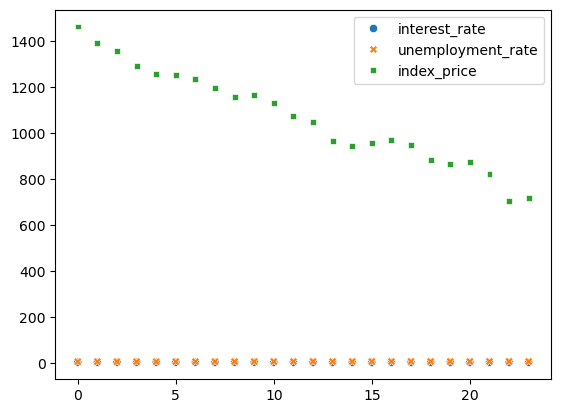

In [5]:
import seaborn as sns
sns.scatterplot(model_data)

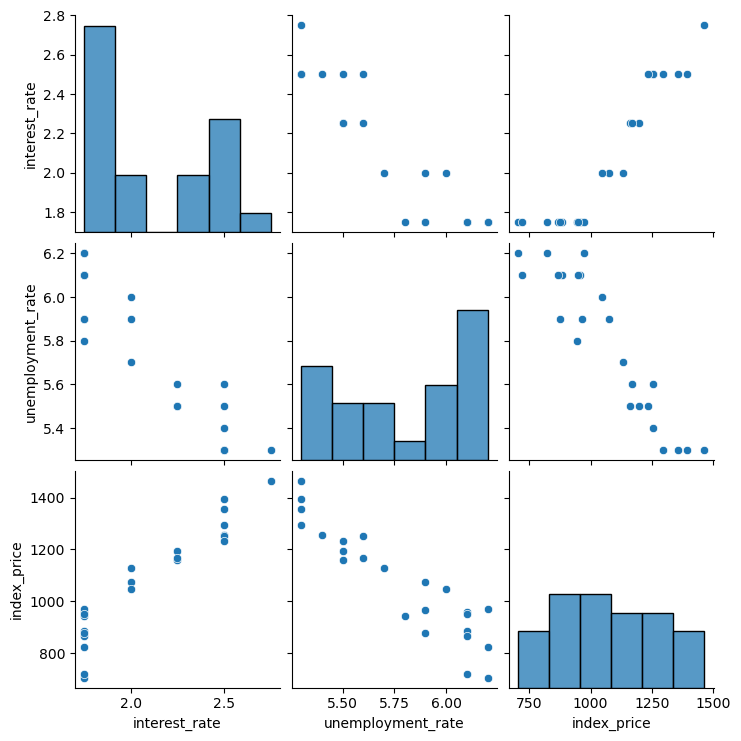

In [6]:
sns.pairplot(model_data)

In [7]:
model_data.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Now lets get our independent features and dependent features

In [8]:
X = model_data.iloc[:, :-1] #All the rows and all the columns but last one
Y = model_data.iloc[:, -1]

In [9]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [10]:
Y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

### Train and test split

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

### Standardizing the train and test data

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print("Training data", x_train)
print(f'Testing data f{x_test}')

Training data [[-0.90115511  0.37908503]
 [ 1.31077107 -1.48187786]
 [-0.90115511  1.30956648]
 [ 1.31077107 -0.55139641]
 [ 1.31077107 -1.48187786]
 [-0.16384638  0.68924552]
 [-0.90115511  0.999406  ]
 [ 1.31077107 -1.48187786]
 [ 1.31077107 -1.17171738]
 [-0.90115511  1.30956648]
 [-0.90115511  0.999406  ]
 [-0.90115511  0.37908503]
 [-0.90115511  0.999406  ]
 [ 0.57346234 -0.8615569 ]
 [-0.16384638 -0.24123593]
 [-0.90115511  0.06892455]
 [-0.90115511  0.999406  ]
 [ 1.31077107 -0.8615569 ]]
Testing data f[[ 0.57346234 -0.8615569 ]
 [-0.90115511  1.30956648]
 [ 2.0480798  -1.48187786]
 [-0.90115511  0.999406  ]
 [-0.16384638  0.37908503]
 [ 0.57346234 -0.55139641]]


### Now our data is ready to be modelled

In [14]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [16]:
regression.fit(x_train, y_train)

LinearRegression()

### Using the sklearn we will cross-validate the score 

In [18]:
from sklearn.model_selection import cross_validate
validation_score = cross_validate(regression, x_train, y_train, scoring='neg_mean_squared_error',
                                 cv=5)

In [19]:
validation_score

{'fit_time': array([0.00288391, 0.00090289, 0.00083041, 0.0007329 , 0.00071311]),
 'score_time': array([0.00086713, 0.00060797, 0.00054979, 0.00051928, 0.00050402]),
 'test_score': array([-1861.74046551, -8715.8459466 , -7707.52362191, -9169.13776461,
         -791.32842311])}

In [21]:
np.mean(validation_score['test_score'])

np.float64(-5649.115244350758)

In [23]:
weights = regression.coef_
weights

array([  88.27275507, -116.25716066])

In [25]:
y_predicted = regression.predict(x_test)
y_predicted

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [ ]:
sns.scatterplot(y_predicted, y_test, )